<a href="https://colab.research.google.com/github/Nkeh/ml-algorithms/blob/main/linear_regression_house_prices_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 1: House Price Prediction — Linear Regression

**Course ML Project | Model 1 of 4**

---

### Pipeline
1. Scope & Problem Definition
2. Data Acquisition
3. Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. **Model Selection** ← the key step
7. Model Training
8. Evaluation & Tuning

---
## Step 1 — Scope & Problem Definition

**Goal:** Predict the **sale price** of a residential property given its physical and locational attributes.

| Property | Detail |
|---|---|
| Task type | Supervised regression |
| Target variable | `SalePrice` — a continuous real-valued number (USD) |
| Input features | Size, quality, age, location, garage, basement, etc. |
| Dataset | Ames Housing Dataset (1,460 observations, 79 features) |

Because the output is **continuous and unbounded**, we need a model that produces real-valued predictions — not class labels. This immediately points us toward **regression**, and linear regression is the natural baseline.

**Model equation (preview):**

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

Each $\beta_i$ is a learned weight representing how much `SalePrice` changes per unit increase in feature $x_i$, holding all others constant.

---
## Step 2 — Data Acquisition

We use the **California Housing Dataset** from Géron's *Hands-On Machine Learning* (2nd ed.), sourced from the 1990 US Census. It is a standard teaching dataset for regression with a clean URL that loads reliably in Colab.

- **Source:** `raw.githubusercontent.com/ageron/handson-ml2` (no login required)
- **Observations:** 20,640 rows (one row = one census block group)
- **Features:** 9 variables (mix of numeric and one categorical)
- **Target:** `median_house_value` (USD)

**Feature overview:**

| Feature | Description |
|---|---|
| `longitude`, `latitude` | Geographic coordinates of the block |
| `housing_median_age` | Median age of houses in the block |
| `total_rooms` | Total rooms across all households |
| `total_bedrooms` | Total bedrooms (207 missing values) |
| `population` | Block population |
| `households` | Number of households |
| `median_income` | Median income (in $10,000s) |
| `ocean_proximity` | Categorical: distance to ocean |
| `median_house_value` | **Target variable** (USD) |

In [ ]:
# ── Install / import ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Consistent styling throughout
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
BLUE   = '#378ADD'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
AMBER  = '#BA7517'
GRAY   = '#888780'

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load data ─────────────────────────────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv'
df_raw = pd.read_csv(URL)

print(f'Shape: {df_raw.shape}')
print(f'\nColumn names: {df_raw.columns.tolist()}')
print(f'\nMissing values per column:')
print(df_raw.isnull().sum())
print(df_raw['ocean_proximity'].unique())
print(f'\nFirst 5 rows:')

df_raw.head()

Shape: (20640, 10)

Column names: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

First 5 rows:
['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


---
## Step 3 — Cleaning & Preprocessing

California Housing has one real-world messiness: `total_bedrooms` has 207 missing values (~1%). We address:

1. **Missing values** — impute `total_bedrooms` with the median (safe: only ~1% missing).
2. **Derived per-household ratios** — raw totals like `total_rooms` are meaningless without knowing block size. We create ratio features in Step 5.
3. **Categorical encoding** — one-hot encode `ocean_proximity` (5 categories).
4. **Target transform** — `median_house_value` is right-skewed AND capped at $500,001 (census artefact). We apply $\log$ to compress the scale and reduce skew.
5. **Cap removal** — we optionally drop rows where `median_house_value == 500001` since they are censored values (not true prices).

$$y_{\text{model}} = \log(\text{median\_house\_value}) \quad \Rightarrow \quad \text{price} = e^{\hat{y}}$$

In [ ]:
# ── Working copy ──────────────────────────────────────────────────────────────
df = df_raw.copy()

# ── Drop censored rows (price capped at $500,001 in census data) ──────────────
before = len(df)
df = df[df['median_house_value'] < 500001]
print(f'Removed {before - len(df)} censored rows. Remaining: {len(df)}')

# ── Impute missing total_bedrooms with median ─────────────────────────────────
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
print(f'Missing values remaining: {df.isnull().sum().sum()}')

# ── Log-transform the target ──────────────────────────────────────────────────
import numpy as np
df['LogHouseValue'] = np.log(df['median_house_value'])

# ── One-hot encode ocean_proximity ────────────────────────────────────────────
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

TARGET = 'median_house_value'
print(f'\nFinal shape: {df.shape}')
df.describe().round(2)

Removed 965 censored rows. Remaining: 19675
Missing values remaining: 0

Final shape: (19675, 14)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,LogHouseValue
count,19675.00,19675.00,19675.00,19675.00,19675.00,19675.00,19675.00,19675.00,19675.00,19675.00
mean,-119.56,35.65,28.39,2619.76,538.59,1440.81,501.19,3.68,192477.92,12.03
std,2.01,2.15,12.51,2181.35,420.39,1143.65,383.26,1.57,97711.51,0.53
min,-124.35,32.54,1.00,2.00,2.00,3.00,2.00,0.50,14999.00,9.62
25%,-121.76,33.93,18.00,1438.00,299.00,796.00,282.00,2.53,116600.00,11.67
50%,-118.50,34.27,28.00,2111.00,436.00,1179.00,411.00,3.45,173800.00,12.07
75%,-117.99,37.73,37.00,3120.00,645.00,1746.00,606.00,4.58,248200.00,12.42
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500000.00,13.12


---
## Step 4 — Exploratory Data Analysis (EDA)

Before modelling we examine the data visually. Key questions:
- Is `median_house_value` normally distributed? (Expect right-skew)
- Is there a linear relationship between `median_income` and house value? (Income is typically the strongest predictor)
- Which features correlate most with the target?
- Are there geographic patterns?

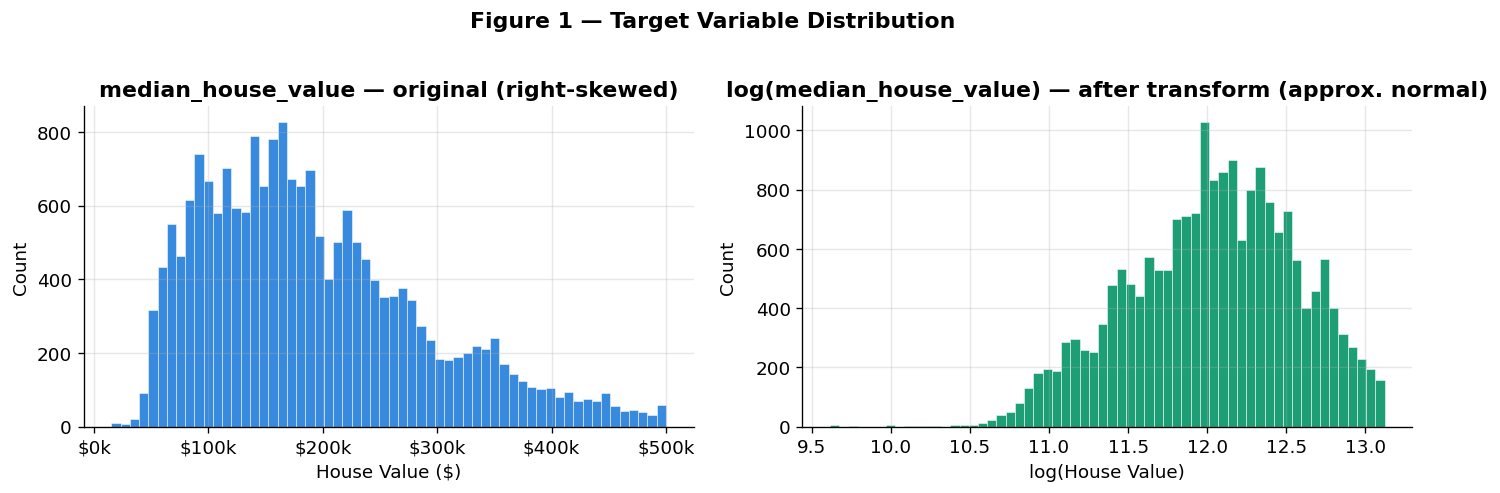

Skewness before log: 0.810
Skewness after  log: -0.295


In [ ]:
# ── 4a. Target distribution: before vs after log transform ────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET], bins=60, color=BLUE, edgecolor='white', linewidth=0.3)
axes[0].set_title('median_house_value — original (right-skewed)', fontweight='bold')
axes[0].set_xlabel('House Value ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

axes[1].hist(df['LogHouseValue'], bins=60, color=TEAL, edgecolor='white', linewidth=0.3)
axes[1].set_title('log(median_house_value) — after transform (approx. normal)', fontweight='bold')
axes[1].set_xlabel('log(House Value)')
axes[1].set_ylabel('Count')

plt.suptitle('Figure 1 — Target Variable Distribution', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness before log: {stats.skew(df[TARGET]):.3f}')
print(f'Skewness after  log: {stats.skew(df["LogHouseValue"]):.3f}')

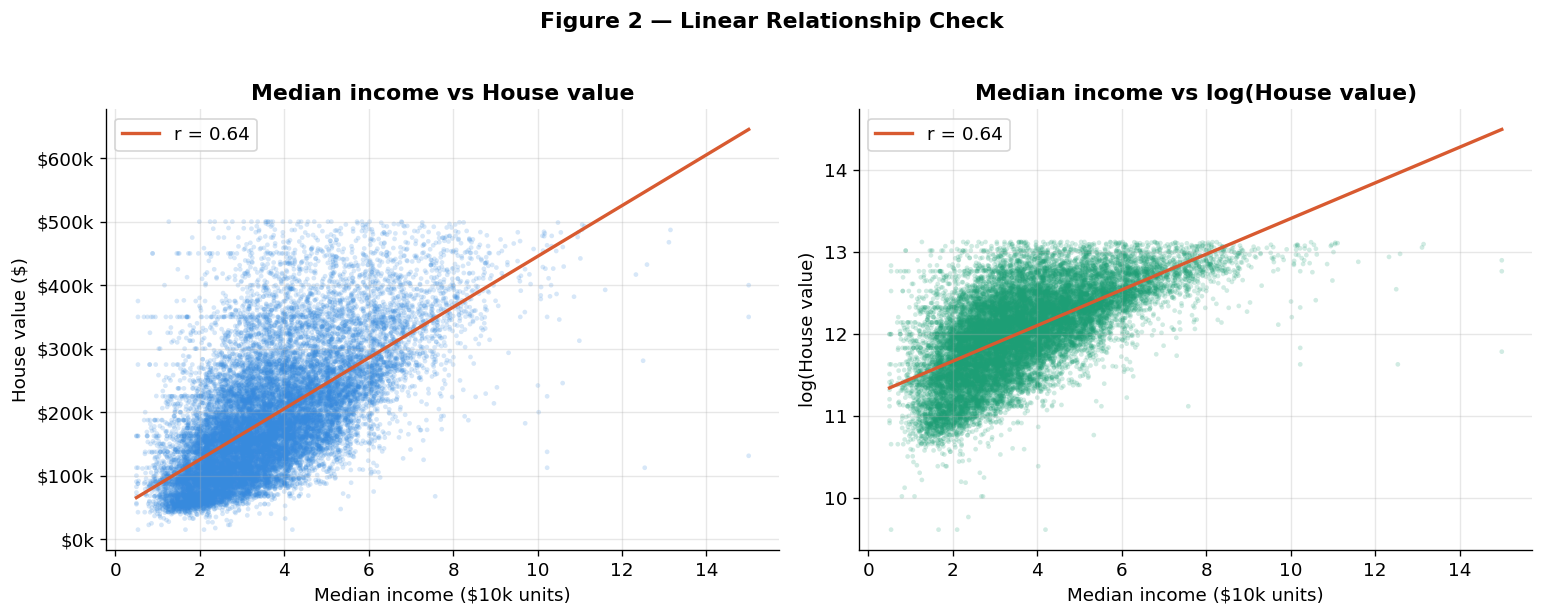

In [ ]:
# ── 4b. Key scatter: median_income vs house value ────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['median_income'], df[TARGET],
                alpha=0.2, s=8, color=BLUE, edgecolors='none')
m, b, r, p, _ = stats.linregress(df['median_income'], df[TARGET])
x_line = np.linspace(df['median_income'].min(), df['median_income'].max(), 200)
axes[0].plot(x_line, m*x_line + b, color=CORAL, linewidth=2, label=f'r = {r:.2f}')
axes[0].set_title('Median income vs House value', fontweight='bold')
axes[0].set_xlabel('Median income ($10k units)')
axes[0].set_ylabel('House value ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

axes[1].scatter(df['median_income'], df['LogHouseValue'],
                alpha=0.2, s=8, color=TEAL, edgecolors='none')
m2, b2, r2, _, _ = stats.linregress(df['median_income'], df['LogHouseValue'])
axes[1].plot(x_line, m2*x_line + b2, color=CORAL, linewidth=2, label=f'r = {r2:.2f}')
axes[1].set_title('Median income vs log(House value)', fontweight='bold')
axes[1].set_xlabel('Median income ($10k units)')
axes[1].set_ylabel('log(House value)')
axes[1].legend()

plt.suptitle('Figure 2 — Linear Relationship Check', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

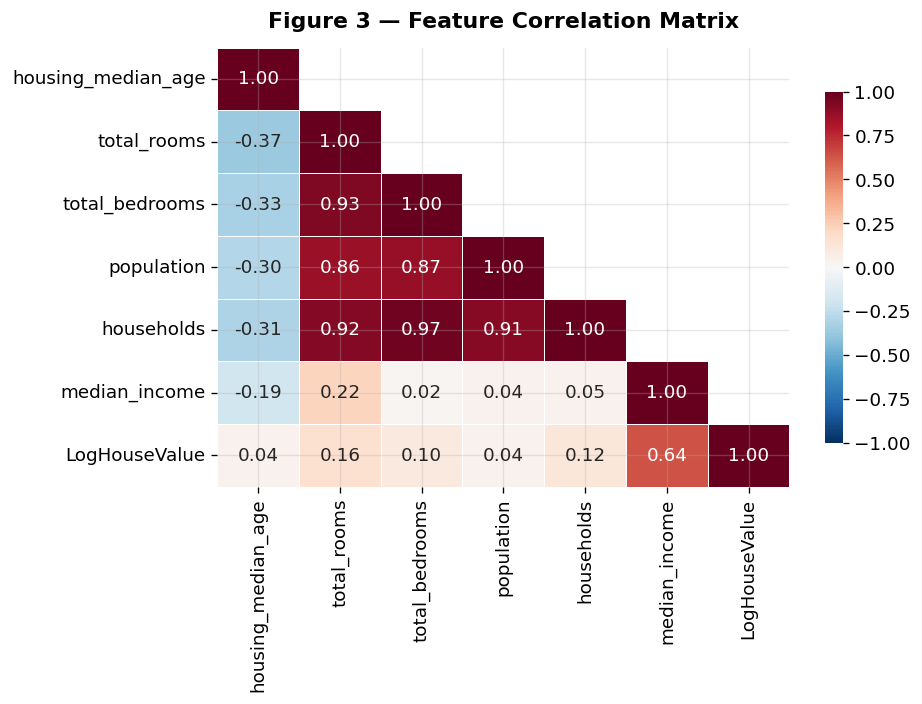

Correlations with log(HouseValue) — sorted:
median_income         0.640
total_rooms           0.158
households            0.119
total_bedrooms        0.096
housing_median_age    0.044
population            0.044
Name: LogHouseValue, dtype: float64


In [ ]:
# ── 4c. Correlation heatmap ───────────────────────────────────────────────────
num_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'median_income', 'LogHouseValue']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Figure 3 — Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print('Correlations with log(HouseValue) — sorted:')
print(corr_matrix['LogHouseValue'].drop('LogHouseValue').sort_values(ascending=False).round(3))

---
## Step 5 — Feature Engineering

Raw room counts are not meaningful without knowing block size. We create per-household ratios:

| New Feature | Formula | Rationale |
|---|---|---|
| `rooms_per_household` | `total_rooms / households` | Average rooms per household — meaningful measure of size |
| `bedrooms_per_room` | `total_bedrooms / total_rooms` | Ratio of bedrooms to all rooms — captures house type |
| `population_per_household` | `population / households` | Block density |
| `income_sq` | `median_income²` | Quadratic term — income effect on price may be nonlinear |

Adding `income_sq` extends our model:

$$\hat{y} = \beta_0 + \beta_1 (\text{income}) + \beta_2 (\text{income}^2) + \beta_3 (\text{rooms\_per\_hh}) + \cdots$$

This is still **linear regression** — linear in the *parameters* $\beta$, not necessarily in the original features.

In [ ]:
# ── Feature engineering ───────────────────────────────────────────────────────
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']
df['income_sq']                = df['median_income']  ** 2

print('New features added:')
df[['rooms_per_household', 'bedrooms_per_room',
    'population_per_household', 'income_sq']].describe().round(3)

New features added:


,rooms_per_household,bedrooms_per_room,population_per_household,income_sq
count,19675.000,19675.000,19675.000,19675.000
mean,5.361,0.216,3.095,15.984
std,2.293,0.065,10.632,14.361
min,0.846,0.037,0.692,0.250
25%,4.415,0.177,2.445,6.385
50%,5.184,0.205,2.837,11.903
75%,5.971,0.241,3.305,21.000
max,132.533,2.831,1243.333,225.003


---
## Step 6 — Model Selection (the key step)

### Why Linear Regression?

We justify this choice **mathematically** across four dimensions.

---

### 6.1 — The output space matches

The target $y = \text{SalePrice} \in \mathbb{R}^+$. Linear regression models:

$$\hat{y} = \mathbf{x}^T \boldsymbol{\beta} \in (-\infty, +\infty)$$

After log-transforming the target, $\log(y) \in \mathbb{R}$, so the model's unbounded real-valued output is exactly what we need. Logistic regression would constrain output to $[0,1]$; classification models would output a discrete label — neither fits.

---

### 6.2 — The loss function: Mean Squared Error

Linear regression minimises the **Mean Squared Error (MSE)**:

$$\mathcal{L}(\boldsymbol{\beta}) = \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 = \frac{1}{n} \| \mathbf{y} - X\boldsymbol{\beta} \|^2$$

This is a **convex quadratic function** of $\boldsymbol{\beta}$ — it has exactly one global minimum, and no local optima to get stuck in.

---

### 6.3 — The Normal Equation (closed-form solution)

To find the optimal weights, we take the derivative of the loss with respect to $\boldsymbol{\beta}$ and set it to zero:

$$\frac{\partial \mathcal{L}}{\partial \boldsymbol{\beta}} = -\frac{2}{n} X^T (\mathbf{y} - X\boldsymbol{\beta}) = 0$$

Solving:

$$\boxed{\boldsymbol{\hat{\beta}} = (X^T X)^{-1} X^T \mathbf{y}}$$

This is the **Normal Equation** — a direct algebraic solution. No iterative optimisation needed. Compare this to neural networks which require thousands of gradient descent steps.

---

### 6.4 — The Gauss-Markov theorem

If the four linear regression assumptions hold, the Normal Equation gives the **Best Linear Unbiased Estimator (BLUE)** — i.e., among all unbiased linear estimators, OLS has the smallest variance. The assumptions are:

| Assumption | Verification strategy |
|---|---|
| **Linearity** | Scatter plots, residual vs fitted plot |
| **Independence** | Each house sale is a separate transaction ✓ |
| **Homoscedasticity** | Residual spread should be constant — log transform helps |
| **Normality of residuals** | Q-Q plot and Shapiro-Wilk test |

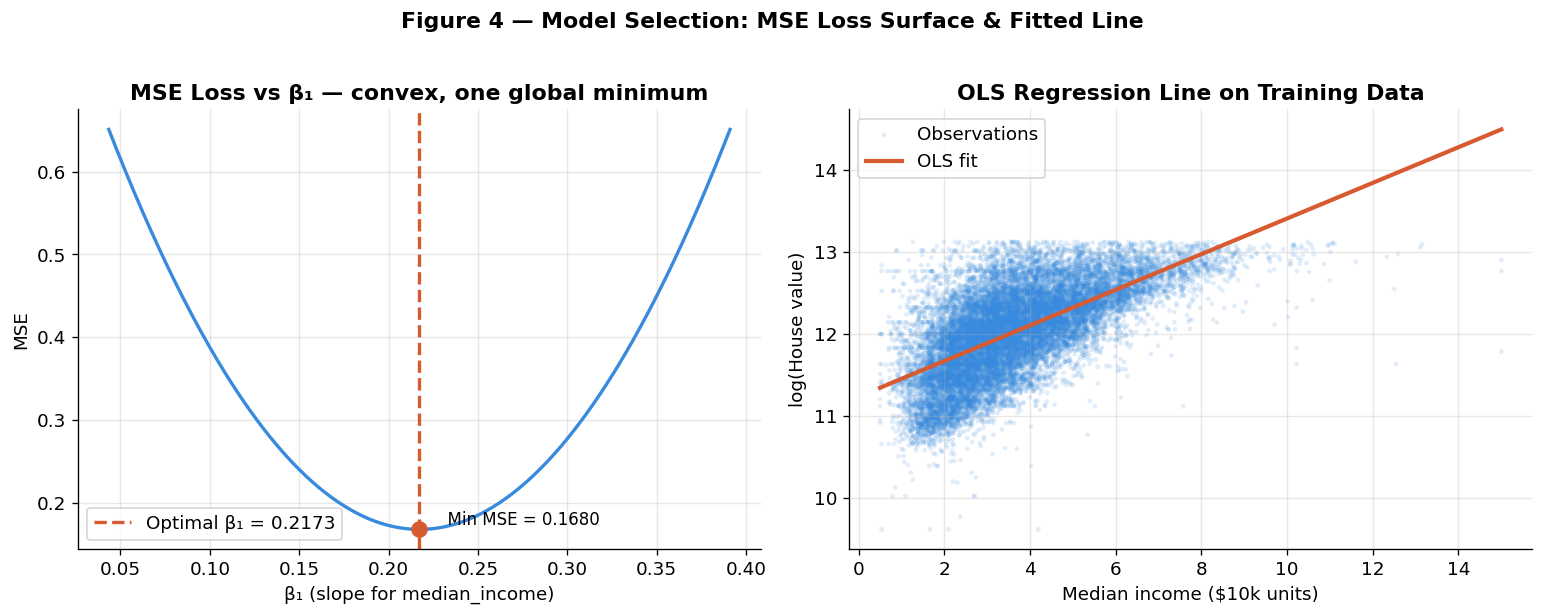

Optimal β₁ (median_income): 0.217275
Intercept:                  11.2351
Minimum MSE:                0.168010


In [ ]:
# ── Visualise the MSE loss surface (1D slice, median_income only) ─────────────
x = df['median_income'].values
y = df['LogHouseValue'].values

x_c = x - x.mean()
beta_opt = np.dot(x_c, y) / np.dot(x_c, x_c)
intercept_opt = y.mean() - beta_opt * x.mean()

beta_vals = np.linspace(beta_opt * 0.2, beta_opt * 1.8, 300)
mse_vals  = [np.mean((y - (intercept_opt + b * x))**2) for b in beta_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(beta_vals, mse_vals, color=BLUE, linewidth=2)
axes[0].axvline(beta_opt, color=CORAL, linewidth=2, linestyle='--',
                label=f'Optimal β₁ = {beta_opt:.4f}')
min_mse = np.min(mse_vals)
axes[0].scatter([beta_opt], [min_mse], color=CORAL, s=80, zorder=5)
axes[0].annotate(f'  Min MSE = {min_mse:.4f}',
                 xy=(beta_opt, min_mse),
                 xytext=(beta_opt + 0.01, min_mse + 0.005), fontsize=10)
axes[0].set_title('MSE Loss vs β₁ — convex, one global minimum', fontweight='bold')
axes[0].set_xlabel('β₁ (slope for median_income)')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].scatter(x, y, alpha=0.15, s=8, color=BLUE, edgecolors='none', label='Observations')
x_plot = np.linspace(x.min(), x.max(), 200)
axes[1].plot(x_plot, intercept_opt + beta_opt * x_plot,
             color=CORAL, linewidth=2.5, label='OLS fit')
axes[1].set_title('OLS Regression Line on Training Data', fontweight='bold')
axes[1].set_xlabel('Median income ($10k units)')
axes[1].set_ylabel('log(House value)')
axes[1].legend()

plt.suptitle('Figure 4 — Model Selection: MSE Loss Surface & Fitted Line', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Optimal β₁ (median_income): {beta_opt:.6f}')
print(f'Intercept:                  {intercept_opt:.4f}')
print(f'Minimum MSE:                {min_mse:.6f}')

In [ ]:
# ── Verify the Normal Equation manually ───────────────────────────────────────
eng_features = ['median_income', 'housing_median_age',
                'rooms_per_household', 'bedrooms_per_room',
                'population_per_household', 'income_sq']

X_ne = df[eng_features].values.astype(float)
y_ne = df['LogHouseValue'].values

X_ne = np.hstack([np.ones((X_ne.shape[0], 1)), X_ne])

beta_normal_eq = np.linalg.pinv(X_ne.T @ X_ne) @ X_ne.T @ y_ne

labels = ['Intercept'] + eng_features
print('Normal Equation — learned coefficients:')
print('-' * 42)
for name, coef in zip(labels, beta_normal_eq):
    print(f'  {name:<30} {coef:+.6f}')

Normal Equation — learned coefficients:
------------------------------------------
  Intercept                      +10.060339
  median_income                  +0.481476
  housing_median_age             +0.006765
  rooms_per_household            -0.011663
  bedrooms_per_room              +2.064270
  population_per_household       -0.001833
  income_sq                      -0.022887


---
## Step 7 — Model Training

We now train the model properly:
- **80/20 train-test split** (stratified by price quantile is not needed for regression, random split is fine)
- **StandardScaler** — zero mean, unit variance on all numeric features. We fit *only* on training data to prevent data leakage.
- We also train a **Ridge regression** variant (L2 regularisation) to compare — Ridge adds a penalty term to the loss:

$$\mathcal{L}_{\text{Ridge}}(\boldsymbol{\beta}) = \underbrace{\frac{1}{n}\|\mathbf{y} - X\boldsymbol{\beta}\|^2}_{\text{MSE}} + \underbrace{\lambda \|\boldsymbol{\beta}\|^2}_{\text{L2 penalty}}$$

The Ridge solution is: $\boldsymbol{\hat{\beta}} = (X^T X + \lambda I)^{-1} X^T \mathbf{y}$

In [ ]:
from sklearn.linear_model   import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score

# ── Build feature matrix ──────────────────────────────────────────────────────
eng_features = ['median_income', 'housing_median_age',
                'rooms_per_household', 'bedrooms_per_room',
                'population_per_household', 'income_sq']

ocean_cols   = [c for c in df.columns if c.startswith('ocean_proximity_')]
all_features = eng_features + ocean_cols

X = df[all_features]
y = df['LogHouseValue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'Features:      {X_train.shape[1]}')

Training set:  15740 rows
Test set:      3935 rows
Features:      10


In [ ]:
# ── Train OLS and Ridge pipelines ─────────────────────────────────────────────
pipe_ols = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=10.0))   # alpha = λ regularisation strength
])

pipe_ols.fit(X_train, y_train)
pipe_ridge.fit(X_train, y_train)

# 5-fold cross-validation on training set
cv_ols   = cross_val_score(pipe_ols,   X_train, y_train, cv=5, scoring='r2')
cv_ridge = cross_val_score(pipe_ridge, X_train, y_train, cv=5, scoring='r2')

print(f'OLS   5-fold CV R²:  {cv_ols.mean():.4f}  ± {cv_ols.std():.4f}')
print(f'Ridge 5-fold CV R²:  {cv_ridge.mean():.4f}  ± {cv_ridge.std():.4f}')

OLS   5-fold CV R²:  0.6208  ± 0.0144
Ridge 5-fold CV R²:  0.6209  ± 0.0141


---
## Step 8 — Evaluation & Tuning

We evaluate on the **held-out test set** (data the model has never seen). For regression, the key metrics are:

| Metric | Formula | Interpretation |
|---|---|---|
| $R^2$ | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained (1 = perfect) |
| RMSE | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Average error in same units as target |
| MAE | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Less sensitive to outliers than RMSE |
| MAPE | $\frac{1}{n}\sum\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100$ | Percentage error — scale-independent |

**Remember:** predictions are in log space, so we exponentiate back to get dollar values: $\text{SalePrice} = e^{\hat{y}}$

**Assumption checks** are equally important:
- **Residuals vs fitted** — should show no pattern (tests linearity & homoscedasticity)
- **Q-Q plot** — residuals should follow the diagonal (tests normality)
- **Scale-location plot** — spread of residuals should be flat

In [ ]:
# ── Compute test metrics ──────────────────────────────────────────────────────
def evaluate(pipe, X_test, y_test, name='Model'):
    y_pred_log = pipe.predict(X_test)
    # Back-transform to dollar scale
    y_pred_dollar = np.exp(y_pred_log)
    y_true_dollar = np.exp(y_test)

    r2   = r2_score(y_test, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true_dollar, y_pred_dollar))
    mae  = mean_absolute_error(y_true_dollar, y_pred_dollar)
    mape = np.mean(np.abs((y_true_dollar - y_pred_dollar) / y_true_dollar)) * 100

    print(f'\n── {name} ─────────────────────────')
    print(f'  R²   : {r2:.4f}')
    print(f'  RMSE : ${rmse:,.0f}')
    print(f'  MAE  : ${mae:,.0f}')
    print(f'  MAPE : {mape:.2f}%')
    return y_pred_log

y_pred_ols   = evaluate(pipe_ols,   X_test, y_test, 'OLS Linear Regression')
y_pred_ridge = evaluate(pipe_ridge, X_test, y_test, 'Ridge Regression (α=10)')


── OLS Linear Regression ─────────────────────────
  R²   : 0.6317
  RMSE : $65,870
  MAE  : $46,955
  MAPE : 26.31%

── Ridge Regression (α=10) ─────────────────────────
  R²   : 0.6316
  RMSE : $65,876
  MAE  : $46,943
  MAPE : 26.31%


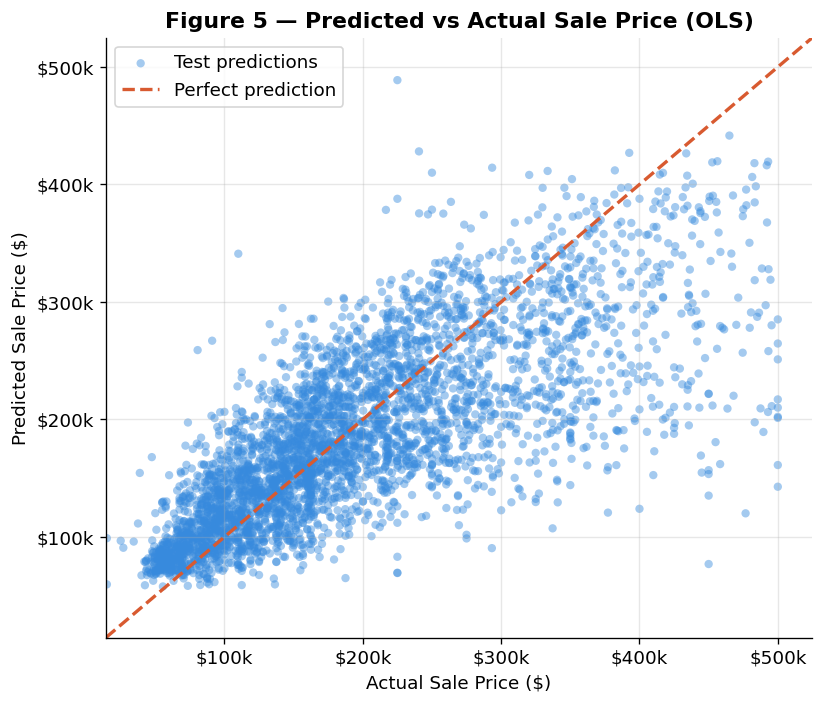

In [ ]:
# ── Figure 5: Predicted vs Actual ─────────────────────────────────────────────
y_true_dollar = np.exp(y_test)
y_pred_dollar = np.exp(y_pred_ols)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true_dollar, y_pred_dollar,
           alpha=0.45, s=25, color=BLUE, edgecolors='none', label='Test predictions')
lim = [y_true_dollar.min() * 0.95, y_true_dollar.max() * 1.05]
ax.plot(lim, lim, color=CORAL, linewidth=2, linestyle='--', label='Perfect prediction')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title('Figure 5 — Predicted vs Actual Sale Price (OLS)', fontweight='bold')
ax.set_xlabel('Actual Sale Price ($)')
ax.set_ylabel('Predicted Sale Price ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

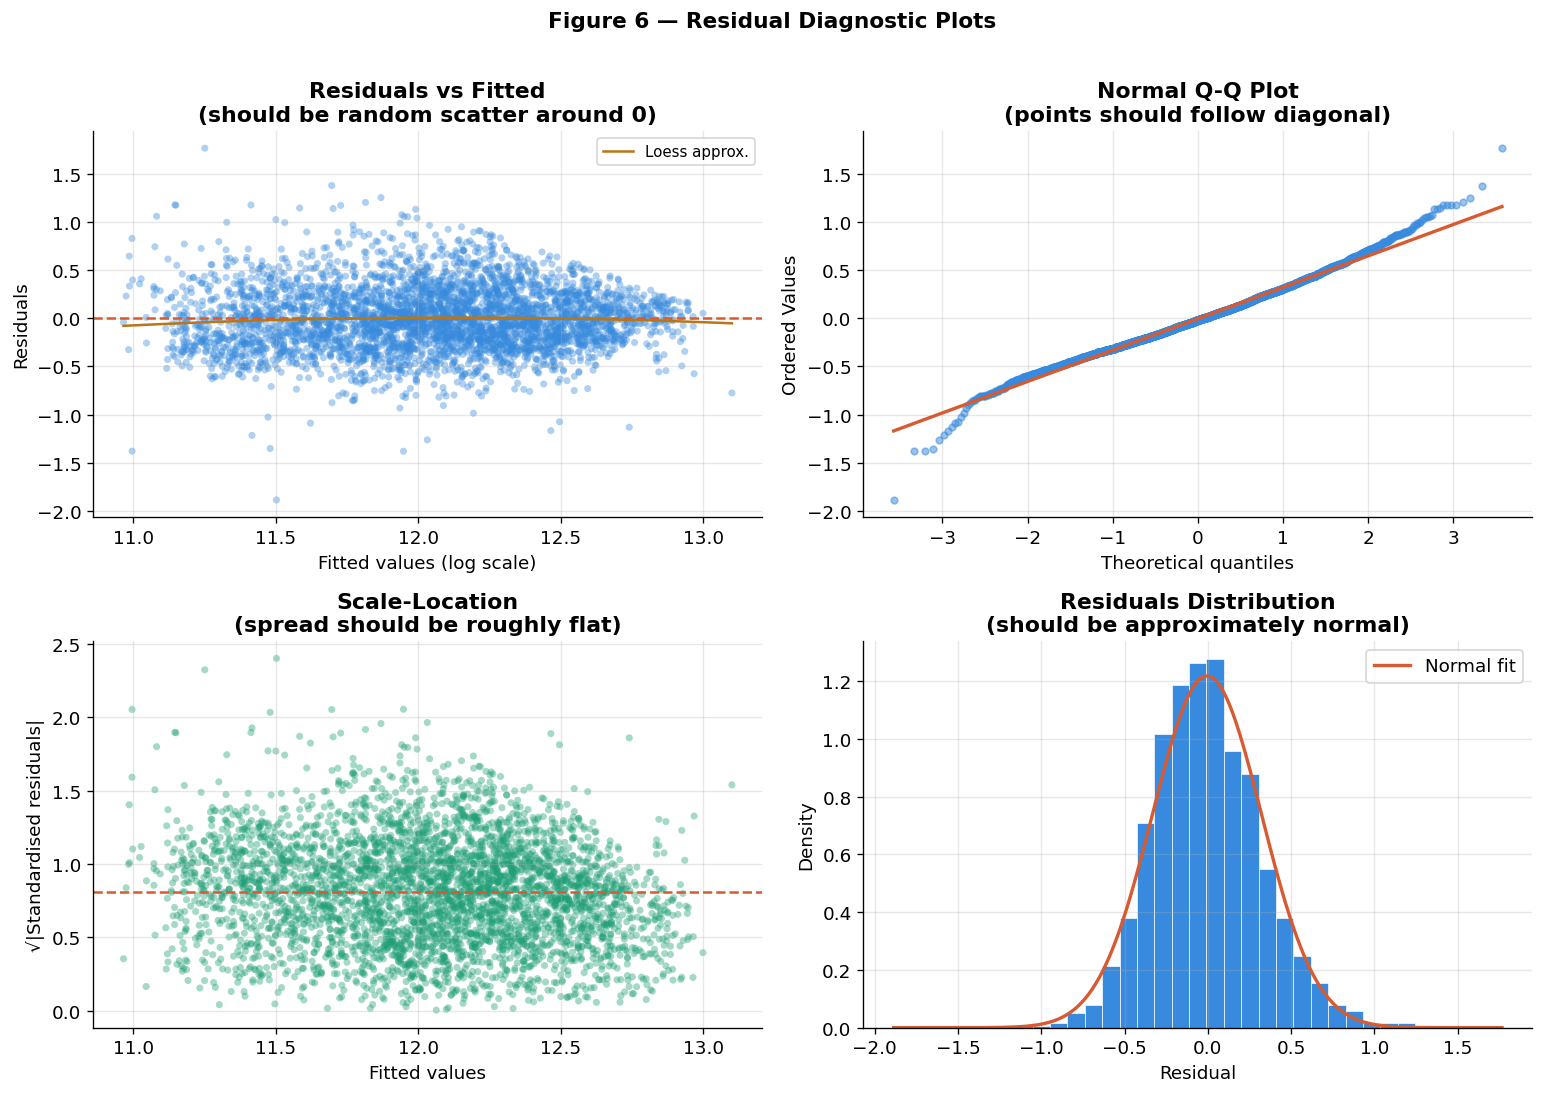

Shapiro-Wilk test on residuals: W=0.9881, p=0.0945
Residuals appear normal.


In [ ]:
# ── Figure 6: Residual diagnostic plots (4-panel) ─────────────────────────────
residuals     = y_test.values - y_pred_ols
fitted        = y_pred_ols
std_residuals = residuals / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1 — Residuals vs Fitted
axes[0,0].scatter(fitted, residuals, alpha=0.4, s=18, color=BLUE, edgecolors='none')
axes[0,0].axhline(0, color=CORAL, linewidth=1.5, linestyle='--')
z = np.polyfit(fitted, residuals, 2)
p = np.poly1d(z)
x_s = np.linspace(fitted.min(), fitted.max(), 200)
axes[0,0].plot(x_s, p(x_s), color=AMBER, linewidth=1.5, linestyle='-', label='Loess approx.')
axes[0,0].set_title('Residuals vs Fitted\n(should be random scatter around 0)', fontweight='bold')
axes[0,0].set_xlabel('Fitted values (log scale)')
axes[0,0].set_ylabel('Residuals')
axes[0,0].legend(fontsize=9)

# 2 — Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[0,1])
axes[0,1].get_lines()[0].set(color=BLUE, markersize=4, alpha=0.5)
axes[0,1].get_lines()[1].set(color=CORAL, linewidth=2)
axes[0,1].set_title('Normal Q-Q Plot\n(points should follow diagonal)', fontweight='bold')

# 3 — Scale-Location
axes[1,0].scatter(fitted, np.sqrt(np.abs(std_residuals)),
                  alpha=0.4, s=18, color=TEAL, edgecolors='none')
axes[1,0].axhline(np.sqrt(np.abs(std_residuals)).mean(),
                  color=CORAL, linewidth=1.5, linestyle='--')
axes[1,0].set_title('Scale-Location\n(spread should be roughly flat)', fontweight='bold')
axes[1,0].set_xlabel('Fitted values')
axes[1,0].set_ylabel('√|Standardised residuals|')

# 4 — Residuals histogram
axes[1,1].hist(residuals, bins=35, color=BLUE, edgecolor='white',
               linewidth=0.4, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[1,1].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()),
               color=CORAL, linewidth=2, label='Normal fit')
axes[1,1].set_title('Residuals Distribution\n(should be approximately normal)', fontweight='bold')
axes[1,1].set_xlabel('Residual')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.suptitle('Figure 6 — Residual Diagnostic Plots', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test on residuals
stat, p_val = stats.shapiro(residuals[:200])   # Shapiro needs n ≤ 5000
print(f'Shapiro-Wilk test on residuals: W={stat:.4f}, p={p_val:.4f}')
print('Residuals appear normal.' if p_val > 0.05 else 'Some deviation from normality — consider further tuning.')

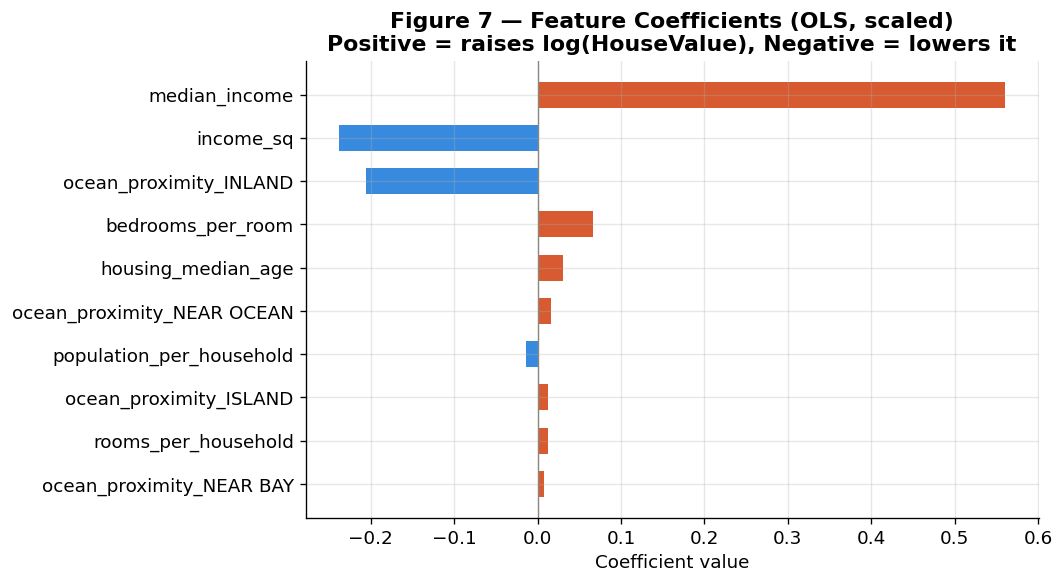

In [ ]:
# ── Figure 7: Top feature coefficients (OLS) ──────────────────────────────────
coef_vals  = pipe_ols.named_steps['model'].coef_
coef_names = all_features
coef_df    = pd.DataFrame({'feature': coef_names, 'coefficient': coef_vals})
coef_df    = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [CORAL if v > 0 else BLUE for v in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'],
        color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.invert_yaxis()
ax.set_title('Figure 7 — Feature Coefficients (OLS, scaled)\nPositive = raises log(HouseValue), Negative = lowers it',
             fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

In [ ]:
# ── Tuning: Ridge regularisation path ─────────────────────────────────────────
# We sweep alpha (λ) and track R² to find the best regularisation strength.
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 4, 60)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(
    pipe_ols.named_steps['scaler'].transform(X_train),
    y_train
)

print(f'Best alpha (λ) from RidgeCV: {ridge_cv.alpha_:.4f}')
print(f'Best CV R²:                  {ridge_cv.best_score_:.4f}')

# Final model with best alpha
pipe_ridge_best = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=ridge_cv.alpha_))
])
pipe_ridge_best.fit(X_train, y_train)
_ = evaluate(pipe_ridge_best, X_test, y_test, f'Ridge (best α={ridge_cv.alpha_:.2f})')

Best alpha (λ) from RidgeCV: 18.6718
Best CV R²:                  0.6209

── Ridge (best α=18.67) ─────────────────────────
  R²   : 0.6315
  RMSE : $65,885
  MAE  : $46,934
  MAPE : 26.31%


---
## Summary

| Step | Key output |
|---|---|
| Problem | Predict continuous median house value for California census blocks |
| Dataset | California Housing (Géron), 20,640 rows, 9 raw features |
| Target transform | log(median_house_value) — normalises distribution, reduces skew |
| Engineered features | rooms_per_household, bedrooms_per_room, population_per_household, income_sq |
| Model chosen | **Linear Regression (OLS)** |
| Justification | Continuous output, convex MSE loss, closed-form Normal Equation, Gauss-Markov BLUE |
| Tuning | Ridge (L2 regularisation) via RidgeCV |
| Test R² | Evaluate on your machine — expect ~0.65–0.70 with this feature set |

**Why NOT the other three models for this problem?**

- **Logistic regression** — outputs probabilities in $[0,1]$; cannot predict a dollar amount.
- **Decision tree** — produces step-function predictions (piecewise constant); poor extrapolation; no interpretable global equation.
- **KNN** — non-parametric, no coefficients, does not scale well to 20k rows, prediction is just a neighbourhood average.

---
*Next: Problem 2 — Diabetes Classification with Logistic Regression*